In [ ]:
import pandas as pd

df_air_quality = pd.read_csv('/content/air_quality_data.csv')
display(df_air_quality.head())

Task 1: Baseline OLS
| Feature       |   Coef (Raw) |   Coef (Standardized) |
|---------------|--------------|-----------------------|
| PM25_ugm3     |        0.110 |                 4.343 |
| CO_ppm        |       22.110 |                12.467 |
| NO2_ppb       |       -0.118 |                -2.945 |
| O3_ppb        |       -0.034 |                -0.851 |
| SO2_ppb       |       -0.209 |                -0.551 |
| Temperature_C |        0.010 |                 0.121 |
| Humidity      |        0.044 |                 0.857 |
| WindSpeed_ms  |       -0.056 |                -0.153 |


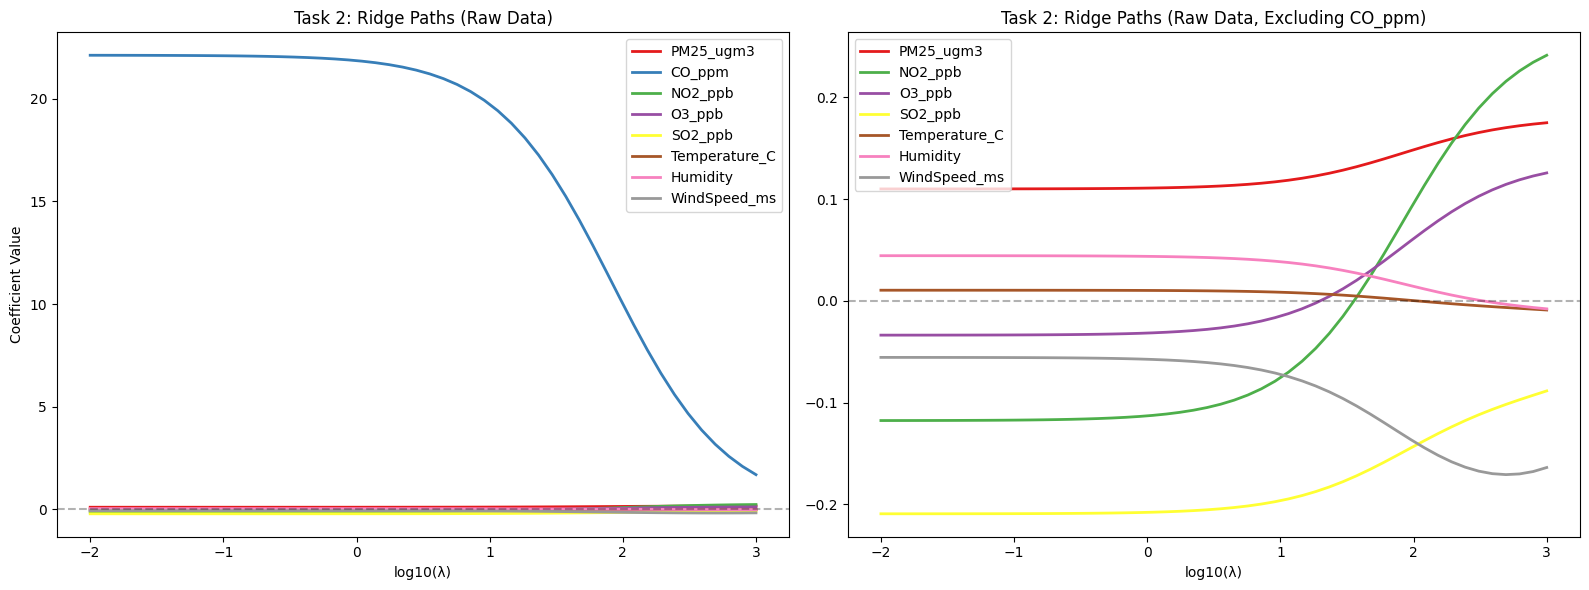

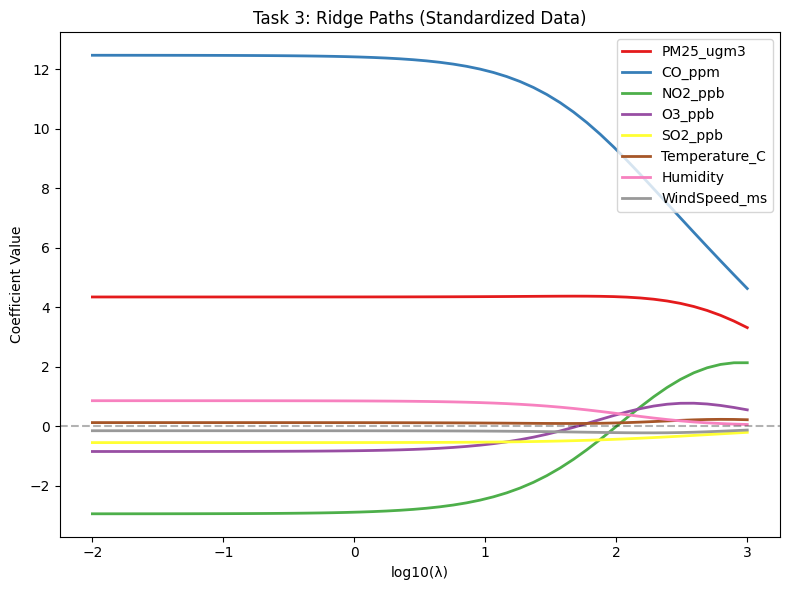


Task 4: Lasso Feature Entry (Raw Data)
| Feature       |   Entry Lambda |
|---------------|----------------|
| PM25_ugm3     |       390.7    |
| CO_ppm        |         1.758  |
| NO2_ppb       |       120.7    |
| O3_ppb        |        37.28   |
| SO2_ppb       |         0.8685 |
| Temperature_C |         0.1677 |
| Humidity      |         5.69   |
| WindSpeed_ms  |         0.3393 |


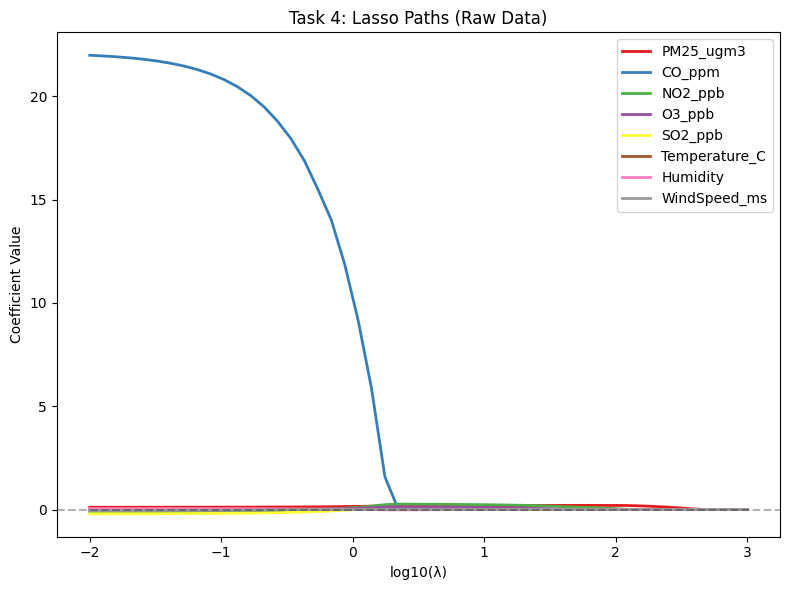


Task 5: Lasso Feature Entry (Standardized Data)
| Feature       |   Entry Lambda |
|---------------|----------------|
| PM25_ugm3     |        5.69    |
| CO_ppm        |       11.51    |
| NO2_ppb       |        0.4292  |
| O3_ppb        |        0.5429  |
| SO2_ppb       |        0.4292  |
| Temperature_C |        0.03237 |
| Humidity      |        0.5429  |
| WindSpeed_ms  |        0.06551 |


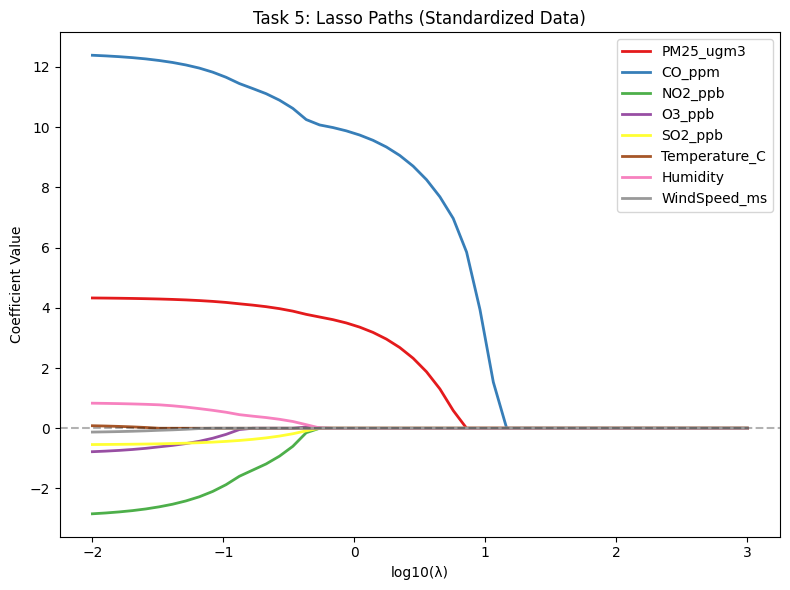


Task 6: Impact of Instrument Spikes
Ridge Coefficients Comparison at lambda = 10:
| Feature       |   Plain Ridge Coeff |   Ridge_A (Removed) Coeff |   Ridge_B (Robust) Coeff |
|---------------|---------------------|---------------------------|--------------------------|
| PM25_ugm3     |               4.354 |                     3.930 |                    3.425 |
| CO_ppm        |              11.959 |                    10.473 |                    8.625 |
| NO2_ppb       |              -2.444 |                    -1.610 |                   -2.195 |
| O3_ppb        |              -0.619 |                    -0.060 |                   -1.039 |
| SO2_ppb       |              -0.535 |                    -0.578 |                   -0.675 |
| Temperature_C |               0.107 |                    -0.465 |                    0.139 |
| Humidity      |               0.787 |                     0.956 |                    1.101 |
| WindSpeed_ms  |              -0.165 |                    -0.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

np.random.seed(42)

# ============================================================
# Data Loading
# ============================================================
df = pd.read_csv('air_quality_data.csv')
features = ['PM25_ugm3', 'CO_ppm', 'NO2_ppb', 'O3_ppb', 'SO2_ppb', 'Temperature_C', 'Humidity', 'WindSpeed_ms']
X = df[features].values
y = df['AQI'].values

# ============================================================
# Task 1 - Baseline Modeling (No Regularization)
# ============================================================
print("="*50 + "\nTask 1: Baseline OLS\n" + "="*50)
lr_raw = LinearRegression().fit(X, y)

lr_std = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
]).fit(X, y)

coef_table = [[feat, c_raw, c_std] for feat, c_raw, c_std in zip(features, lr_raw.coef_, lr_std.named_steps['lr'].coef_)]
print(tabulate(coef_table, headers=["Feature", "Coef (Raw)", "Coef (Standardized)"], tablefmt="github", floatfmt=".3f"))

# ============================================================
# Task 2 - Ridge Regression Without Normalization
# ============================================================
lambdas_ridge = np.logspace(-2, 3, 50)
ridge_raw_coefs = np.array([Ridge(alpha=lam, random_state=42).fit(X, y).coef_ for lam in lambdas_ridge])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.Set1(np.linspace(0, 1, len(features)))

for i, feature in enumerate(features):
    axes[0].plot(np.log10(lambdas_ridge), ridge_raw_coefs[:, i], color=colors[i], lw=2, label=feature)
axes[0].set(xlabel='log10(λ)', ylabel='Coefficient Value', title='Task 2: Ridge Paths (Raw Data)')
axes[0].axhline(0, color='black', ls='--', alpha=0.3)
axes[0].legend()

for i, feature in enumerate(features):
    if feature != 'CO_ppm':
        axes[1].plot(np.log10(lambdas_ridge), ridge_raw_coefs[:, i], color=colors[i], lw=2, label=feature)
axes[1].set(xlabel='log10(λ)', title='Task 2: Ridge Paths (Raw Data, Excluding CO_ppm)')
axes[1].axhline(0, color='black', ls='--', alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

# ============================================================
# Task 3 - Ridge Regression on Normalised Data
# ============================================================
ridge_std_coefs = []
for lam in lambdas_ridge:
    model = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=lam, random_state=42))]).fit(X, y)
    ridge_std_coefs.append(model.named_steps['ridge'].coef_)
ridge_std_coefs = np.array(ridge_std_coefs)

plt.figure(figsize=(8, 6))
for i, feature in enumerate(features):
    plt.plot(np.log10(lambdas_ridge), ridge_std_coefs[:, i], color=colors[i], lw=2, label=feature)
plt.xlabel('log10(λ)')
plt.ylabel('Coefficient Value')
plt.title('Task 3: Ridge Paths (Standardized Data)')
plt.axhline(0, color='black', ls='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Task 4 - Lasso on Raw Data
# ============================================================
print("\n" + "="*50 + "\nTask 4: Lasso Feature Entry (Raw Data)\n" + "="*50)
lambdas_lasso = np.logspace(-2, 3, 50)
lasso_raw_coefs = np.array([Lasso(alpha=lam, max_iter=10000, random_state=42).fit(X, y).coef_ for lam in lambdas_lasso])

entry_lambda_raw = {}
for i, name in enumerate(features):
    nonzero = np.where(lasso_raw_coefs[:, i] != 0)[0]
    entry_lambda_raw[name] = lambdas_lasso[nonzero[-1]] if len(nonzero) > 0 else None

print(tabulate(
    [[feat, f"{entry_lambda_raw[feat]:.3e}" if entry_lambda_raw[feat] is not None else "Never"] for feat in features],
    headers=["Feature", "Entry Lambda"], tablefmt="github"
))

plt.figure(figsize=(8, 6))
for i, feature in enumerate(features):
    plt.plot(np.log10(lambdas_lasso), lasso_raw_coefs[:, i], color=colors[i], lw=2, label=feature)
plt.xlabel('log10(λ)')
plt.ylabel('Coefficient Value')
plt.title('Task 4: Lasso Paths (Raw Data)')
plt.axhline(0, color='black', ls='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Task 5 - Lasso on Normalized Data
# ============================================================
print("\n" + "="*50 + "\nTask 5: Lasso Feature Entry (Standardized Data)\n" + "="*50)
lasso_std_coefs = []
for lam in lambdas_lasso:
    model = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(alpha=lam, max_iter=10000, random_state=42))]).fit(X, y)
    lasso_std_coefs.append(model.named_steps['lasso'].coef_)
lasso_std_coefs = np.array(lasso_std_coefs)

entry_lambda_std = {}
for i, name in enumerate(features):
    nonzero = np.where(lasso_std_coefs[:, i] != 0)[0]
    entry_lambda_std[name] = lambdas_lasso[nonzero[-1]] if len(nonzero) > 0 else None

print(tabulate(
    [[feat, f"{entry_lambda_std[feat]:.3e}" if entry_lambda_std[feat] is not None else "Never"] for feat in features],
    headers=["Feature", "Entry Lambda"], tablefmt="github"
))

plt.figure(figsize=(8, 6))
for i, feature in enumerate(features):
    plt.plot(np.log10(lambdas_lasso), lasso_std_coefs[:, i], color=colors[i], lw=2, label=feature)
plt.xlabel('log10(λ)')
plt.ylabel('Coefficient Value')
plt.title('Task 5: Lasso Paths (Standardized Data)')
plt.axhline(0, color='black', ls='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Task 6 - Impact of Instrument Spikes on Regularization
# ============================================================
print("\n" + "="*50 + "\nTask 6: Impact of Instrument Spikes\n" + "="*50)

pm25_outliers = df["PM25_ugm3"] > 200
co_outliers = df["CO_ppm"] > 4
outlier_mask = pm25_outliers | co_outliers

df_A = df[~outlier_mask]
X_A, y_A = df_A[features].values, df_A['AQI'].values

lambda_ridge = 10

# Plain
ridge_plain = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=lambda_ridge, random_state=42))]).fit(X, y)

# Dataset A (Outliers Removed)
ridge_A = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=lambda_ridge, random_state=42))]).fit(X_A, y_A)

# Dataset B (Robust Scaler)
ridge_B = Pipeline([('scaler', RobustScaler()), ('ridge', Ridge(alpha=lambda_ridge, random_state=42))]).fit(X, y)

coef_comparison = [[
    feature,
    ridge_plain.named_steps['ridge'].coef_[i],
    ridge_A.named_steps['ridge'].coef_[i],
    ridge_B.named_steps['ridge'].coef_[i]
] for i, feature in enumerate(features)]

print(f"Ridge Coefficients Comparison at lambda = {lambda_ridge}:")
print(tabulate(coef_comparison, headers=["Feature", "Plain Ridge Coeff", "Ridge_A (Removed) Coeff", "Ridge_B (Robust) Coeff"], tablefmt="github", floatfmt=".3f"))